In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("grandmaster07/student-exam-performance-dataset-analysis")

print("Path to dataset files:", path)

c:\Users\DynaBook\Downloads\AAI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 93.9k/93.9k [00:00<00:00, 965kB/s]

Extracting files...
Path to dataset files: C:\Users\DynaBook\.cache\kagglehub\datasets\grandmaster07\student-exam-performance-dataset-analysis\versions\1


##Analysis Conclusion (will expand later, especially at the end of the notebook)


Through ML and Clasical Regression Analysis, we can see that:

    Negative environments have an impact on the Exam Scores, variables like Low/Medium Teacher Quality or Low/Medium Parental Envolvement had a negative coefficient while having a P-Value below 0.05, meaning they were statistical significant.
    
    Numerical values with statistical significance had high results in t-statistics values, meaning they are good predictors to the main variable. The top metrics are "Attendance" and "Hours of Study".

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

import os

os.listdir(path)

['StudentPerformanceFactors.csv']

In [3]:
file = os.path.join(path,"StudentPerformanceFactors.csv")
df = pd.read_csv(file)

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [5]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

<Axes: xlabel='Exam_Score', ylabel='Count'>

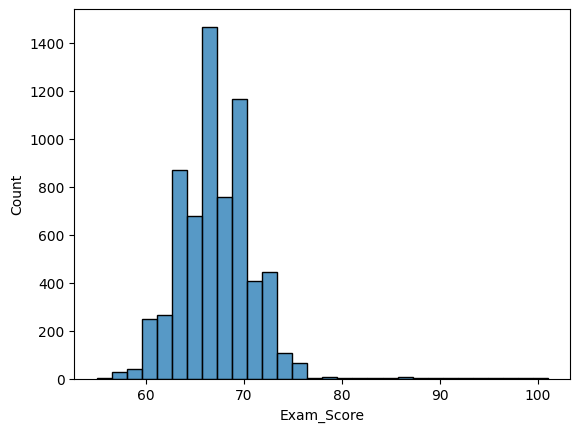

In [6]:
sns.histplot(data = df,x= "Exam_Score",bins =30)

#understanding that most of the exam scores will fall between 65 and 70pts, previous line demonstrated that the mean is 67.23 pts.

In [7]:
df.groupby("Physical_Activity").agg(
   Exam_Score = ("Exam_Score", "mean"),
    Count = ("Physical_Activity", "count")
)

,Exam_Score,Count
Physical_Activity,,
0,67.521739,46
1,66.969121,421
2,67.185003,1627
3,67.196071,2545
4,67.313016,1575
5,67.603878,361
6,68.093750,32


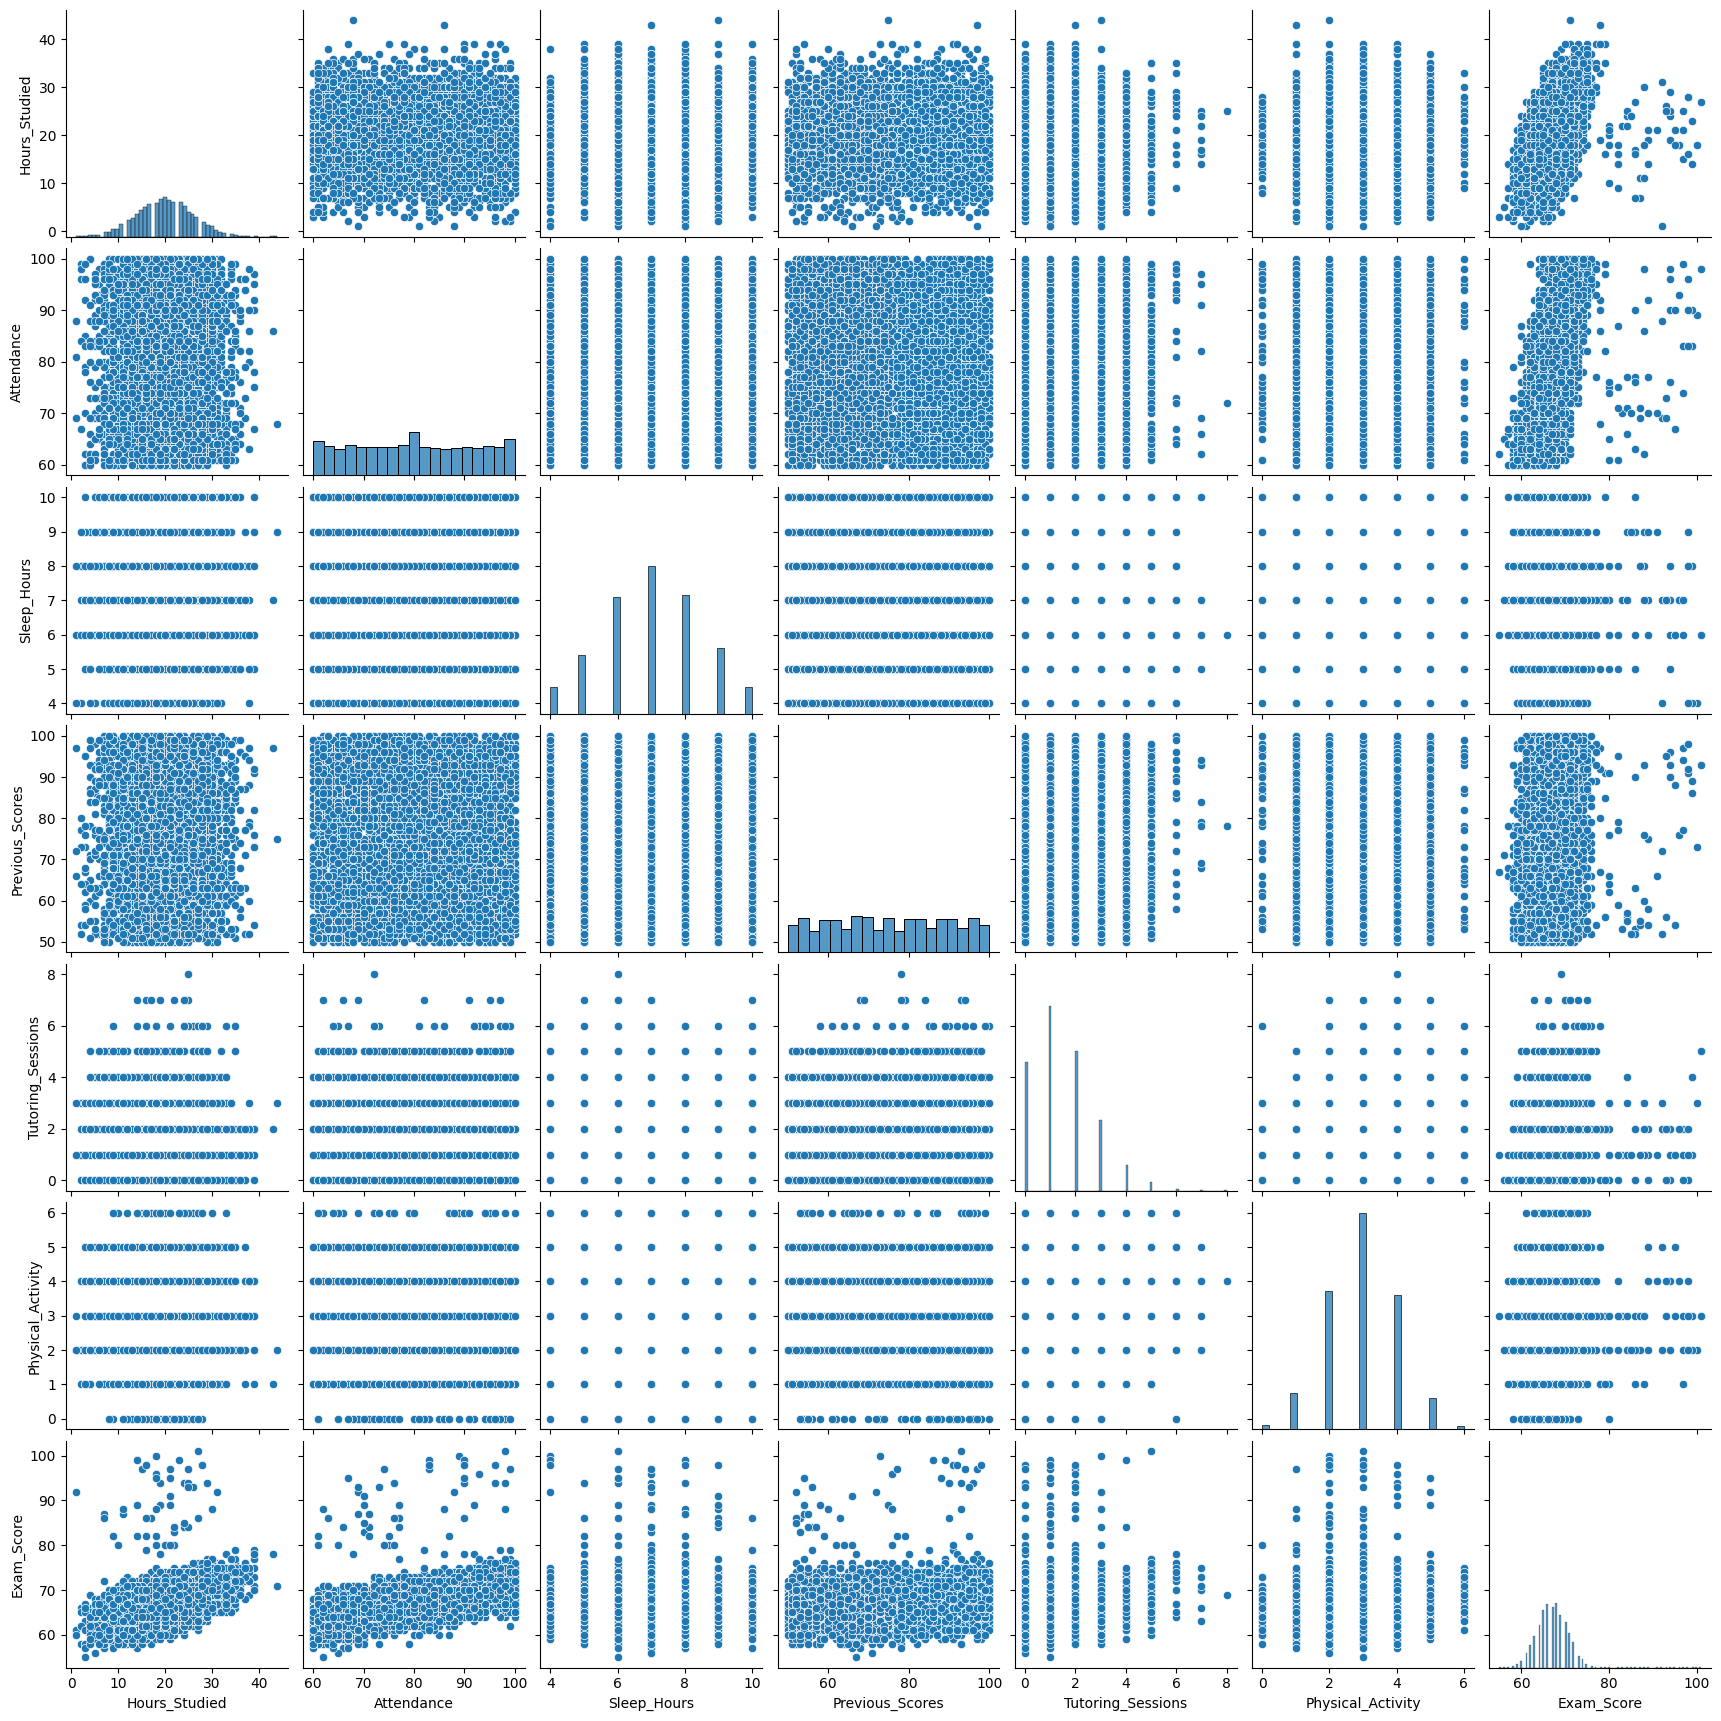

In [8]:
sns.pairplot(df)

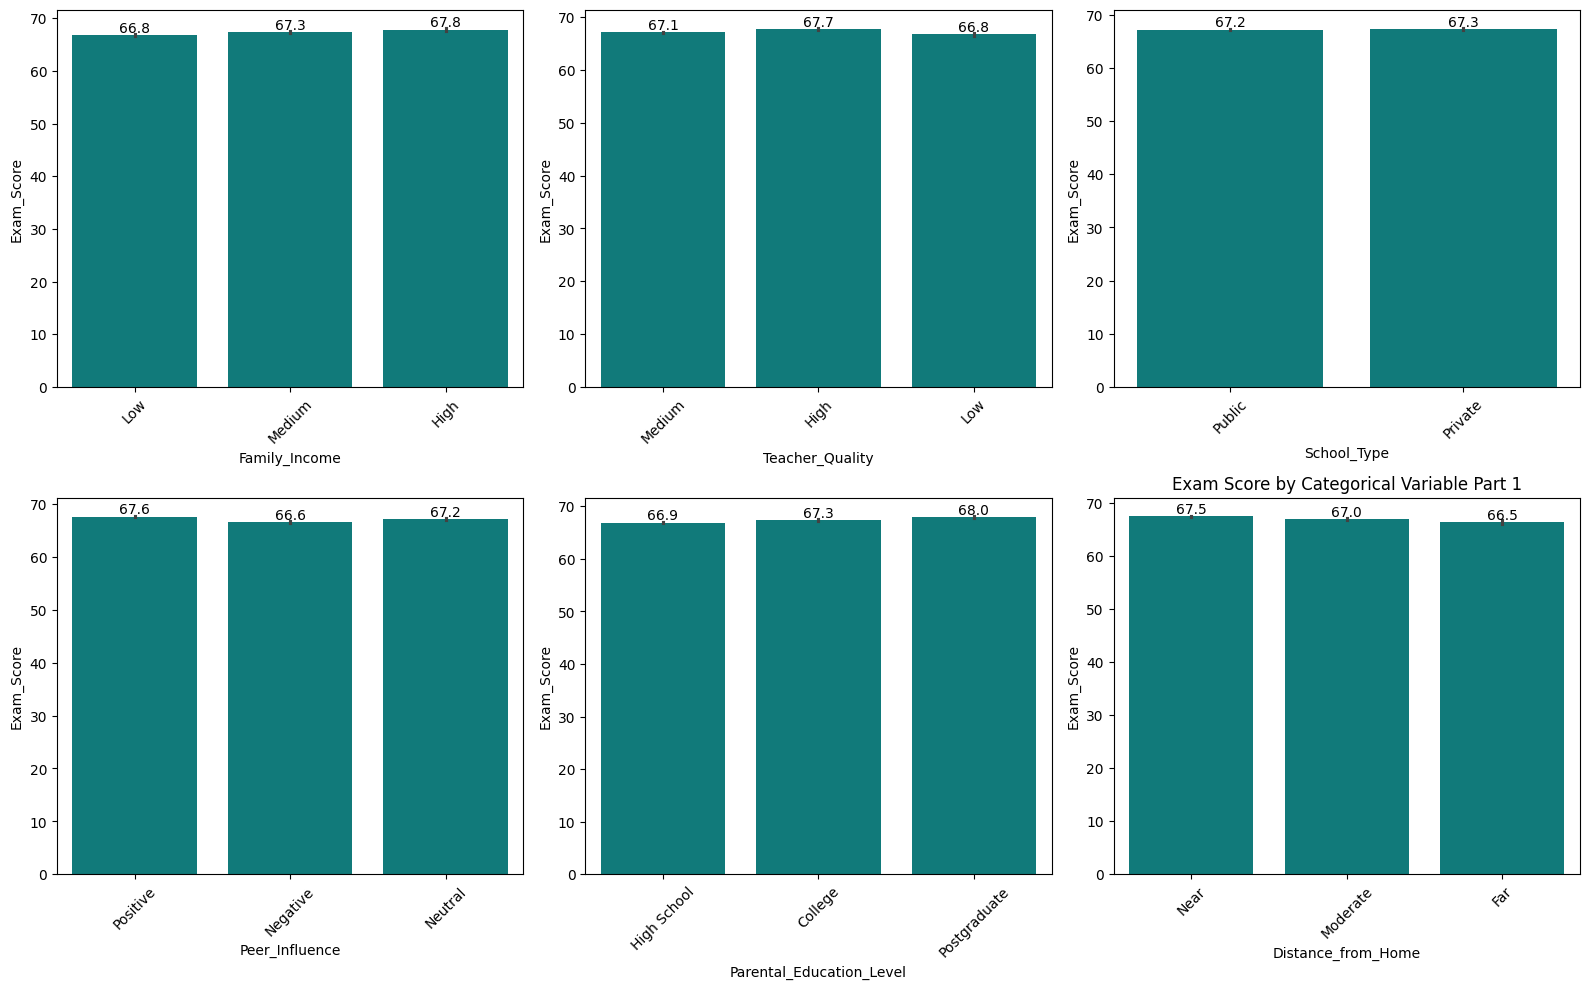

In [9]:
num_target = "Exam_Score"
cat_cols = ["Family_Income", "Teacher_Quality", "School_Type", "Peer_Influence", "Parental_Education_Level", "Distance_from_Home"]

n_cols = 3
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16,10))
axes = axes.flatten()
plt.title("Exam Score by Categorical Variable Part 1")

for i, col in enumerate(cat_cols):
    ax = sns.barplot(data=df, x=col, y="Exam_Score", ax=axes[i],color="darkcyan")
    axes[i].tick_params(axis='x', rotation=45)
    
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f')

plt.tight_layout()
plt.show()

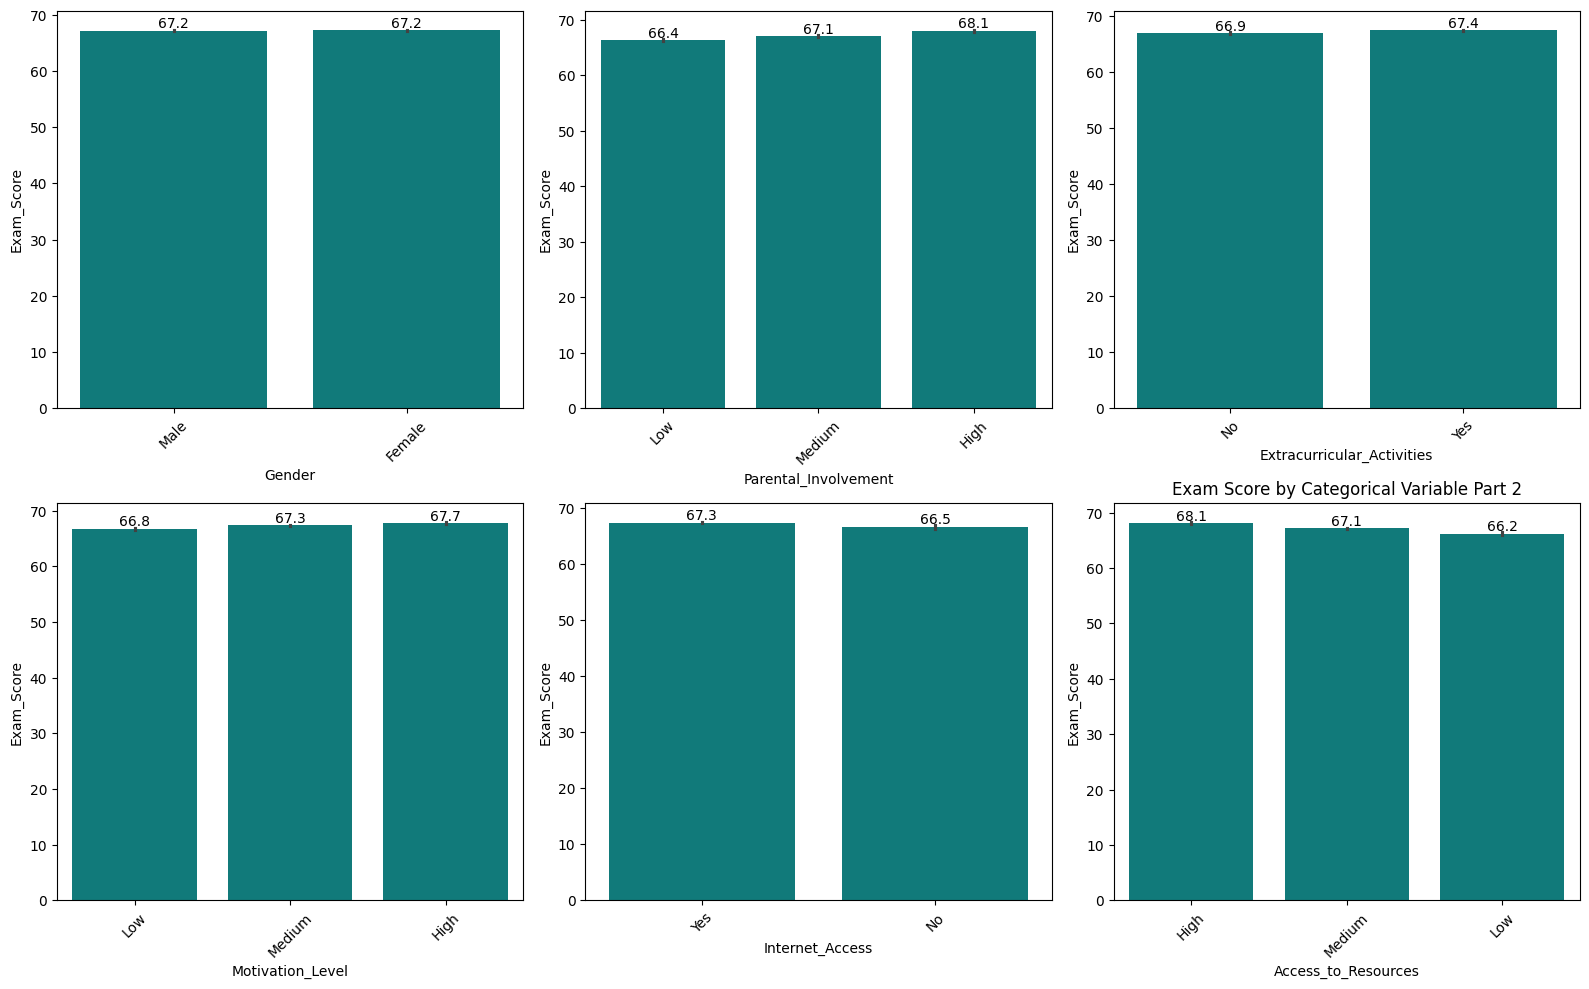

In [10]:
num_target = "Exam_Score"
cat_cols = [ "Gender","Parental_Involvement","Extracurricular_Activities", "Motivation_Level","Internet_Access","Access_to_Resources"]

n_cols = 3
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16,10))
axes = axes.flatten()
plt.title("Exam Score by Categorical Variable Part 2")

for i, col in enumerate(cat_cols):
    ax = sns.barplot(data=df, x=col, y="Exam_Score", ax=axes[i],color="darkcyan")
    axes[i].tick_params(axis='x', rotation=45)
    
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f')

plt.tight_layout()
plt.show()

looking at all categorical values, no category alone seems to explain the variation in the exam score.

## Will run an ML regression model using the numerical values

In [12]:
from sklearn.model_selection import train_test_split

X= df[['Hours_Studied', 'Attendance', 'Sleep_Hours',
       'Previous_Scores', 'Tutoring_Sessions','Physical_Activity']]
y = df['Exam_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [14]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
print("Intercept: ", lm.intercept_)

coeff_df = pd.DataFrame(lm.coef_,X.columns,columns=['Coefficient'])
coeff_df

Intercept:  40.78652683296454


,Coefficient
Hours_Studied,0.288578
Attendance,0.200511
Sleep_Hours,-0.029988
Previous_Scores,0.049348
Tutoring_Sessions,0.523799
Physical_Activity,0.126651


##by using this model, all variables but one have a positive effect in the main metric, being "Tutoring Sessions" the one with the highest coefficient.


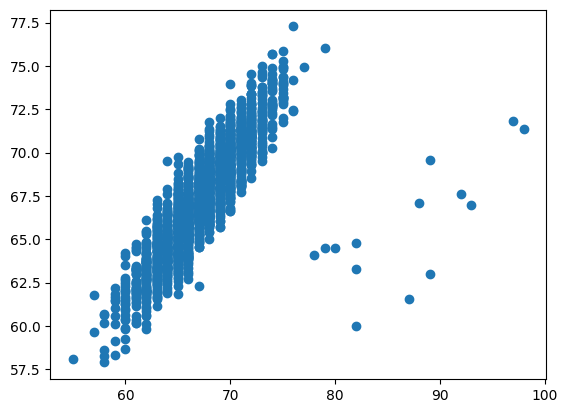

In [16]:
predictions = lm.predict(X_test)
plt.scatter(y_test,predictions)

In [18]:
from sklearn import metrics

print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))


MAE: 1.289796822877547
MSE: 5.049507112620023
RMSE: 2.2471108367457138


##looking at the model results, we see that the model predicts the exam scores by having an acceptable Mean Error of 1.28 pts.

##Looking for P-Values and R-squared values

Runing a classic Regression Analysis with numerical values:

In [20]:
import statsmodels.api as sm
import statsmodels.formula.api as smf


model = smf.ols(formula = 'Exam_Score ~ Hours_Studied + Attendance + Sleep_Hours + Previous_Scores + Tutoring_Sessions + Physical_Activity',
        data = df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.598
Model:                            OLS   Adj. R-squared:                  0.598
Method:                 Least Squares   F-statistic:                     1638.
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:20:56   Log-Likelihood:                -15338.
No. Observations:                6607   AIC:                         3.069e+04
Df Residuals:                    6600   BIC:                         3.074e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            40.9271      0.33

##The model has an "acceptable" performance at explaining the variation in "Exam Scores" by having an R-sq value of 0.598.  Could be better, but is meaningfull

##Looking at the Coefficient table, similar values from the ML are showing, however, when looking at the P-Value, we see that "Sleep Hours" is not statistically significant to the model, which can also explain the negative coefficient.

##The t-statistic column (t), shows "Attendance" as the main predictor, a simple conclusion could be "going to classes get you a better score"


In [21]:
#adding categorical values to the equation
##I'm removing the "Sleep_Hours" from the calculation as it wasn't statisctically significant in the previous exercise

model = smf.ols(
    formula = """
    Exam_Score ~ Hours_Studied + Attendance + Previous_Scores + Tutoring_Sessions + Physical_Activity
    + C(Family_Income)
    + C(Teacher_Quality)
    + C(School_Type)
    + C(Peer_Influence)
    + C(Parental_Involvement)
    + C(Access_to_Resources)
    + C(Extracurricular_Activities)
    + C(Motivation_Level)	
    + C(Internet_Access)
    + C(Parental_Education_Level)	
    + C(Distance_from_Home)
    + C(Gender)
    """,
    data = df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.717
Model:                            OLS   Adj. R-squared:                  0.716
Method:                 Least Squares   F-statistic:                     644.4
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:21:37   Log-Likelihood:                -13725.
No. Observations:                6378   AIC:                         2.750e+04
Df Residuals:                    6352   BIC:                         2.768e+04
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

##The model has a "strong" performance at explaining the variation in "Exam Scores" by having an R-sq value of 0.717 and an R-sq adjusted of 0.716 can be considered high values at the statistical level.

##There are two variables that don't have a statistical significance to "Exam Scores", these are "School type" and "Gender with P-Values above 0.05, these variables are not meaningful to the main metric and could be removed from the model.

##There are some categories with negative coefficients, like Fam Income Low and Medium, Teacher Quality Low and Medium, Parental Involvement, etc. Meaning that unsupportive environments have a negative influence on the student.

##The t-statistic column (t), shows "Attendance" as the main predictor, a simple conclusion could be "going to classes get you a better score"